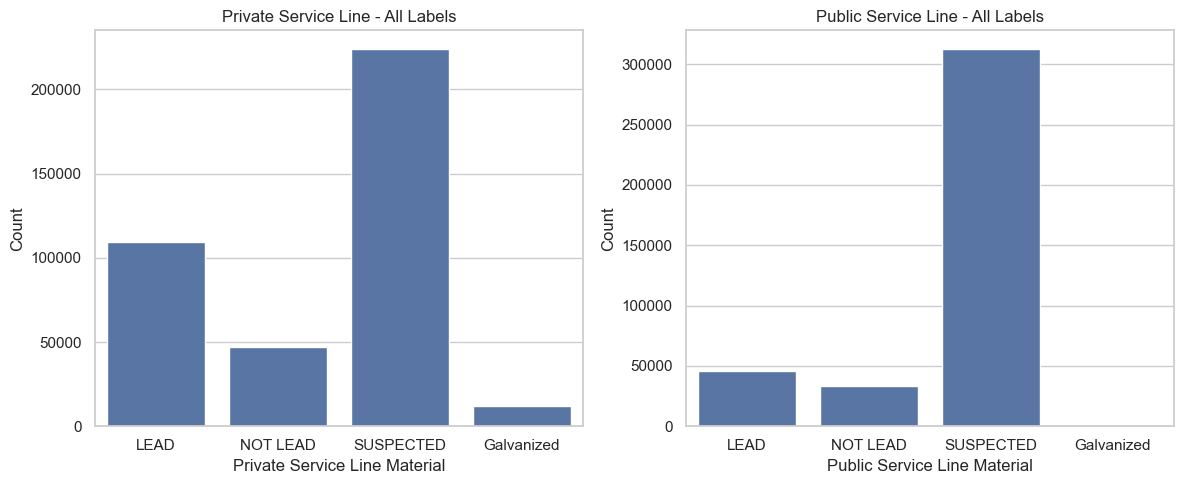

Private Service Line Distribution (Confirmed):
Private Service Line Material
LEAD        69.85
NOT LEAD    30.15
Name: proportion, dtype: float64

Public Service Line Distribution (Confirmed):
Public Service Line Material
LEAD        58.12
NOT LEAD    41.88
Name: proportion, dtype: float64


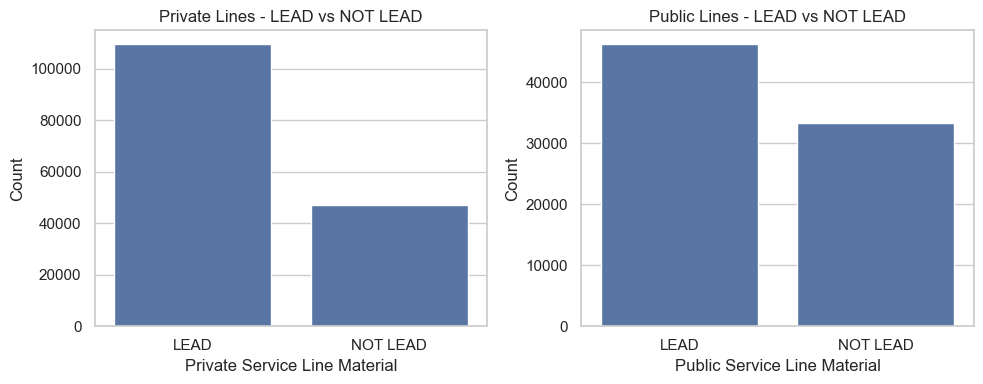

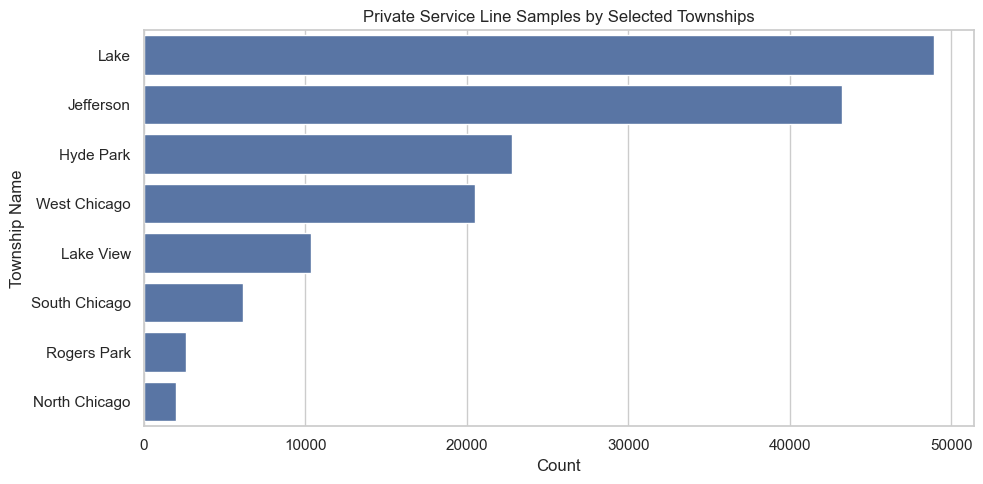

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# load dataset
df = pd.read_csv("assessor_rm_sli_merged.csv", low_memory=False)

# simplify service line labels
df["Private Service Line Material"] = df["Private Service Line Material"].replace({
    "GALVANIZED REQUIRING REPLACEMENT": "Galvanized",
    "SUSPECTED LEAD": "SUSPECTED"
})
df["Public Service Line Material"] = df["Public Service Line Material"].replace({
    "GALVANIZED REQUIRING REPLACEMENT": "Galvanized",
    "SUSPECTED LEAD": "SUSPECTED"
})

# raw distribution plots before filtering
fig, axs = plt.subplots(1, 2, figsize=(12, 5))
sns.countplot(x="Private Service Line Material", data=df, ax=axs[0], order=["LEAD", "NOT LEAD", "SUSPECTED", "Galvanized"])
axs[0].set_title("Private Service Line - All Labels")
axs[0].set_ylabel("Count")

sns.countplot(x="Public Service Line Material", data=df, ax=axs[1], order=["LEAD", "NOT LEAD", "SUSPECTED", "Galvanized"])
axs[1].set_title("Public Service Line - All Labels")
axs[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

# filter for confirmed lead/not lead only
df_private_confirmed = df[df["Private Service Line Material"].isin(["LEAD", "NOT LEAD"])]
df_public_confirmed = df[df["Public Service Line Material"].isin(["LEAD", "NOT LEAD"])]

# print class distribution percentages
private_dist = df_private_confirmed["Private Service Line Material"].value_counts(normalize=True) * 100
public_dist = df_public_confirmed["Public Service Line Material"].value_counts(normalize=True) * 100

print("Private Service Line Distribution (Confirmed):")
print(private_dist.round(2))
print("\nPublic Service Line Distribution (Confirmed):")
print(public_dist.round(2))

# plot confirmed-only distributions
fig, axs = plt.subplots(1, 2, figsize=(10, 4))
sns.countplot(x="Private Service Line Material", data=df_private_confirmed, ax=axs[0], order=["LEAD", "NOT LEAD"])
axs[0].set_title("Private Service Line Material Distribution")
axs[0].set_ylabel("Count")

sns.countplot(x="Public Service Line Material", data=df_public_confirmed, ax=axs[1], order=["LEAD", "NOT LEAD"])
axs[1].set_title("Public Service Line Material Distribution")
axs[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

# define list of townships to include
selected_townships = [
    "Lake", "Jefferson", "Hyde Park", "West Chicago",
    "Lake View", "South Chicago", "Rogers Park", "North Chicago"
]

# filter for selected townships
df_township_filtered = df_private_confirmed[df_private_confirmed["township_name"].isin(selected_townships)]

# plot township_name distribution (confirmed rows only)
plt.figure(figsize=(10, 5))
sns.countplot(
    y="township_name",
    data=df_township_filtered,
    order=df_township_filtered["township_name"].value_counts().index
)
plt.title("Private Service Line Samples by Selected Townships")
plt.xlabel("Count")
plt.ylabel("Township Name")
plt.tight_layout()
plt.show()
